# Metaorder signal — tuning study (Binance BTCUSDT)

**Methodology:** structural parameters are fit **only** on the **calibration** window. Hyperparameters of `SignalConfig` and `BacktestConfig` are **grid-searched on the validation window** (maximize validation final equity). The winner is run **once** on the **test** window.

**Caveat:** Tuning to maximize validation PnL can still **overfit**; test results are not a live-trading guarantee.

In [1]:
%matplotlib inline
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
if not (REPO / "src").is_dir():
    REPO = REPO.parent
os.chdir(REPO)
print("repo root:", REPO.resolve())

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 120

repo root: /Users/patrickcassidy/Desktop/metaorder-modelling-gebbie-


In [2]:
from metaorder_signal.empirical.binance_public import fetch_agg_trades
from metaorder_signal.empirical.calibration import calibrate_from_trades
from metaorder_signal.empirical.tuning import grid_search_signal_backtest, three_way_time_split

CACHE = REPO / "data" / "binance_BTCUSDT_tuning.csv"
MAX_TRADES = 12_000

CACHE.parent.mkdir(parents=True, exist_ok=True)
if CACHE.is_file():
    # Avoid parse_dates= — CSV rows can mix subsecond precision; one strict format then breaks.
    tape = pd.read_csv(CACHE)
    tape["timestamp"] = pd.to_datetime(tape["timestamp"], utc=True, format="mixed")
    print(f"Loaded cache {CACHE} rows={len(tape):,}")
else:
    print("Fetching Binance (requires network)…")
    raw = fetch_agg_trades("BTCUSDT", max_trades=MAX_TRADES)
    tape = raw[["timestamp", "mid", "quantity", "sign"]].copy()
    tape.to_csv(CACHE, index=False)
    print(f"Saved {len(tape):,} rows to {CACHE}")

tape.head()

Loaded cache /Users/patrickcassidy/Desktop/metaorder-modelling-gebbie-/data/binance_BTCUSDT_tuning.csv rows=1,002


,timestamp,mid,quantity,sign
0,2026-05-10 07:54:59.392000+00:00,80746.26,0.00145,1
1,2026-05-10 07:54:59.541000+00:00,80746.25,0.00363,-1
2,2026-05-10 07:55:00.511000+00:00,80746.25,0.00449,-1
3,2026-05-10 07:55:00.670000+00:00,80746.26,0.00012,1
4,2026-05-10 07:55:00.894000+00:00,80746.25,0.00027,-1


In [3]:
cal, val, tst = three_way_time_split(tape, calib_frac=0.40, val_frac=0.30)
print("calib", len(cal), "val", len(val), "test", len(tst))

cp = calibrate_from_trades(cal, min_runs=40)
structural = cp.to_signal_params()
print("alpha=", structural.alpha, "sigma_d=", structural.sigma_d, "vd=", structural.vd)

calib 401 val 300 test 301
Calculating best minimal value for power law fit


Fitting xmin:   0%|          | 0/10 [00:00<?, ?it/s]

Fitting xmin: 100%|██████████| 10/10 [00:00<00:00, 99.95it/s]

Fitting xmin: 100%|██████████| 10/10 [00:00<00:00, 95.57it/s]

alpha= 1.7821777343749994 sigma_d= 8.800051383389402e-06 vd= 5.5134



/Users/patrickcassidy/Desktop/metaorder-modelling-gebbie-/.venv/lib/python3.14/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


In [4]:
print("Grid search on VALIDATION only (48 configs)…")
result = grid_search_signal_backtest(
    structural,
    val,
    tst,
    s_max=8000.0,
    maximize="final_equity",
)
print("Best config:\n", json.dumps(result.best_config, indent=2))
print("Validation metrics:", json.dumps(result.validation_metrics, indent=2))
print("TEST metrics:", json.dumps(result.test_metrics, indent=2))

Grid search on VALIDATION only (48 configs)…


Best config:
 {
  "p_min": 0.58,
  "phi_entry": 0.5,
  "rho_max": 2.4,
  "n_min": 2,
  "phi_exit": 0.88,
  "half_spread": 0.00011,
  "kappa": 0.005,
  "s_max": 8000.0
}
Validation metrics: {
  "final_equity": 0.0013051691999633594,
  "mean_equity_step": 4.350563999877866e-06,
  "vol_equity_step": 0.00012406375267659064,
  "sharpe_like": 0.60738110260229,
  "max_drawdown": 0.8821974794173548,
  "n_trades_signal": 300,
  "n_entries": 15,
  "ic_survival_fwd_ret": 0.08664852720488965,
  "baseline_final_equity": null
}
TEST metrics: {
  "final_equity": 0.0017451727199758915,
  "sharpe_like": 0.5875309399538735,
  "n_entries": 11,
  "max_drawdown": 0.3389253380528167,
  "ic": -0.09628467305233897
}


### Heatmap: validation final equity vs `p_min` and `phi_entry`

**Final equity** here means the **last value** of the backtest’s cumulative equity curve on the **validation** time segment only (same definition as the tuner’s objective).

The grid search varies **more than two** parameters (`rho_max`, `n_min`, half-spread, `kappa`, …). This plot fixes **only** `p_min` (rows) and `phi_entry` (columns). For each cell, the number shown is the **maximum validation final equity** over **all** grid rows that share that `p_min` and `phi_entry` — i.e. “if we lock these two knobs, what’s the best we could do on validation by tuning the rest?”

**Why it looks like three flat stripes:** the coarse grid has **only three** `p_min` levels and **two** `phi_entry` levels, so the figure is always a tiny **3×2** lattice — three horizontal bands by construction. Within a band, left vs right often looks **flat** because re-tuning the other params for each `phi` can land on **similar** best validation equity, so the colour scale shows almost no left–right contrast (even when the printed numbers differ a bit).

**Two panels in the next cell:** (1) **Max over grid** — for each `(p_min, phi)` pair, the best validation equity if every other knob is chosen optimally for that pair. (2) **Rest frozen to `best_config`** — apples-to-apples: only `p_min` and `phi_entry` move; marginal sensitivity without other knobs absorbing the effect.


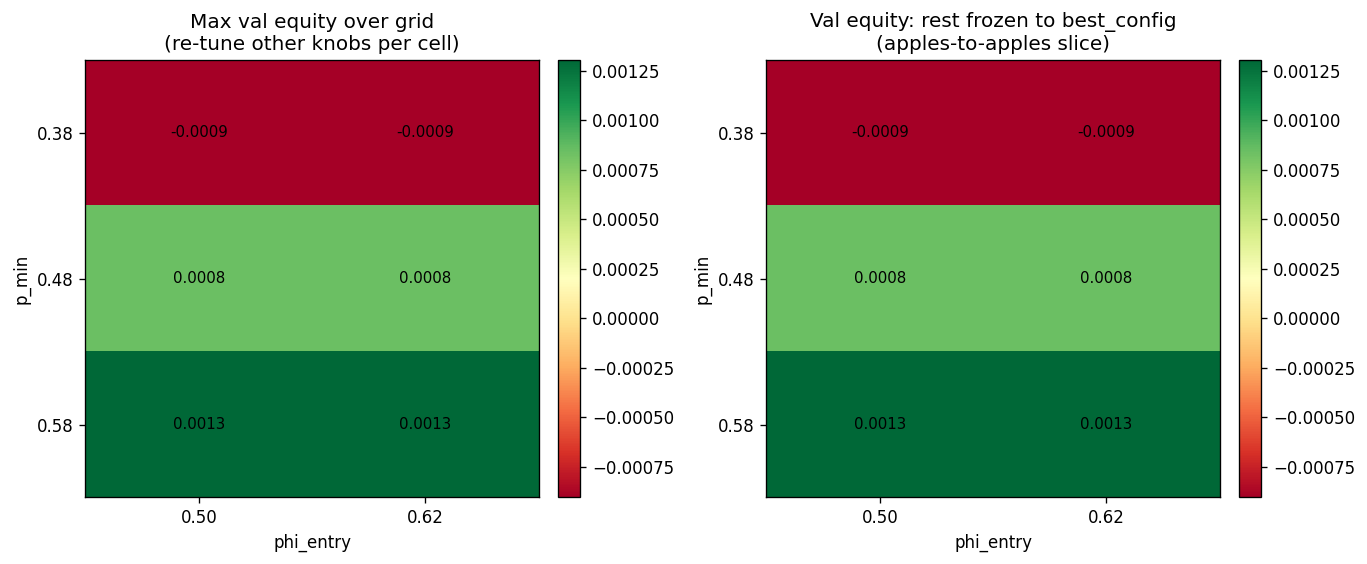

In [5]:
from metaorder_signal.backtest import BacktestConfig, run_event_backtest
from metaorder_signal.signal import SignalConfig

g = result.grid_rows.copy()
pivot = g.pivot_table(
    index="p_min",
    columns="phi_entry",
    values="val_final_equity",
    aggfunc="max",
)

# Apples-to-apples: vary only p_min × phi_entry; freeze rest at winning config
bcfg_fix = BacktestConfig(half_spread_frac=result.best_config["half_spread"])
fixed_rows = []
for pm in pivot.index:
    for pe in pivot.columns:
        scfg = SignalConfig(
            p_min=float(pm),
            phi_entry=float(pe),
            rho_max=result.best_config["rho_max"],
            n_min=int(result.best_config["n_min"]),
            phi_exit=result.best_config["phi_exit"],
            s_max=result.best_config["s_max"],
            kappa_cost=result.best_config["kappa"],
        )
        out = run_event_backtest(val, structural, scfg, bcfg_fix)
        fixed_rows.append(
            {"p_min": pm, "phi_entry": pe, "eq": float(out["equity"].iloc[-1])}
        )
gf = pd.DataFrame(fixed_rows)
pivot_fix = gf.pivot(index="p_min", columns="phi_entry", values="eq")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.8))

for ax, pv, title in (
    (
        ax0,
        pivot,
        "Max val equity over grid\n(re-tune other knobs per cell)",
    ),
    (
        ax1,
        pivot_fix,
        "Val equity: rest frozen to best_config\n(apples-to-apples slice)",
    ),
):
    arr = pv.values.astype(float)
    im = ax.imshow(arr, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels([f"{x:.2f}" for x in pv.columns])
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels([f"{x:.2f}" for x in pv.index])
    ax.set_xlabel("phi_entry")
    ax.set_ylabel("p_min")
    ax.set_title(title)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(
                j,
                i,
                f"{arr[i, j]:.4f}",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
            )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(REPO / "notebooks" / "fig_heatmap_val_equity.png", dpi=140)
plt.show()


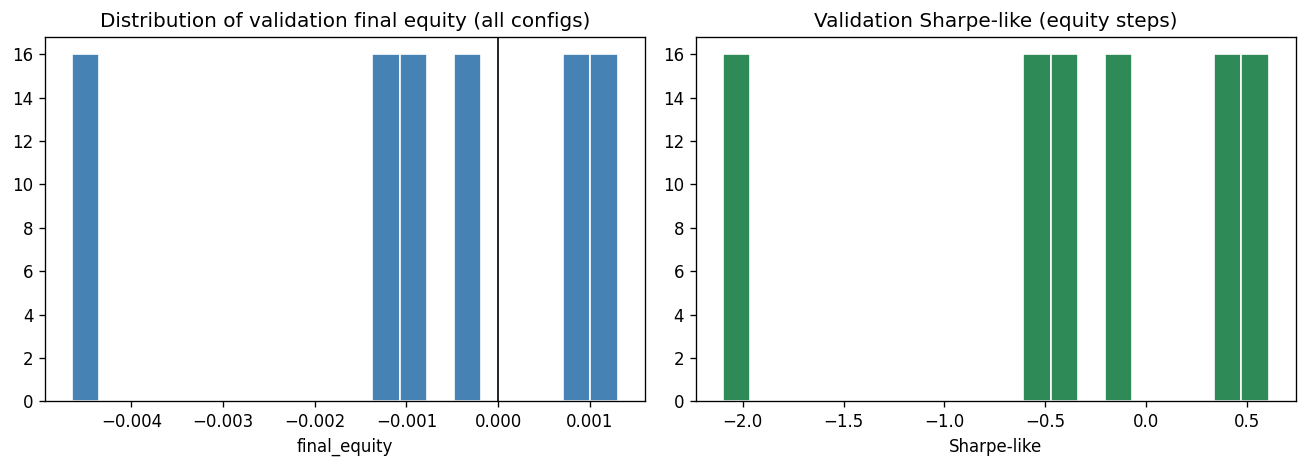

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(g["val_final_equity"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Distribution of validation final equity (all configs)")
axes[0].set_xlabel("final_equity")

axes[1].hist(g["val_sharpe_like"].replace([np.inf, -np.inf], np.nan).dropna(), bins=20, color="seagreen", edgecolor="white")
axes[1].set_title("Validation Sharpe-like (equity steps)")
axes[1].set_xlabel("Sharpe-like")

plt.tight_layout()
plt.savefig(REPO / "notebooks" / "fig_grid_distributions.png", dpi=140)
plt.show()

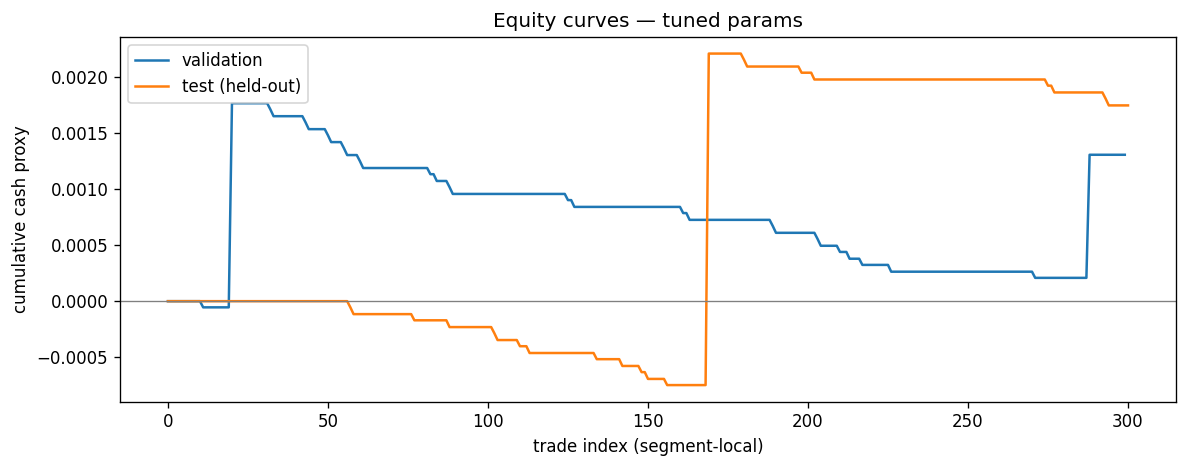

TEST final equity: 0.0017451727199758915


In [7]:
from metaorder_signal.backtest import BacktestConfig, run_event_backtest
from metaorder_signal.signal import SignalConfig

bcfg = BacktestConfig(half_spread_frac=result.best_config["half_spread"])
scfg = SignalConfig(
    p_min=result.best_config["p_min"],
    phi_entry=result.best_config["phi_entry"],
    rho_max=result.best_config["rho_max"],
    n_min=int(result.best_config["n_min"]),
    phi_exit=result.best_config["phi_exit"],
    s_max=result.best_config["s_max"],
    kappa_cost=result.best_config["kappa"],
)

out_val = run_event_backtest(val, structural, scfg, bcfg)
out_test = run_event_backtest(tst, structural, scfg, bcfg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(out_val["equity"].values, label="validation", color="tab:blue")
ax.plot(out_test["equity"].values, label="test (held-out)", color="tab:orange")
ax.axhline(0, color="gray", lw=0.8)
ax.legend()
ax.set_title("Equity curves — tuned params")
ax.set_xlabel("trade index (segment-local)")
ax.set_ylabel("cumulative cash proxy")
plt.tight_layout()
plt.savefig(REPO / "notebooks" / "fig_equity_val_vs_test.png", dpi=140)
plt.show()

print("TEST final equity:", float(out_test["equity"].iloc[-1]))

## Figures saved

- `notebooks/fig_heatmap_val_equity.png`
- `notebooks/fig_grid_distributions.png`
- `notebooks/fig_equity_val_vs_test.png`

If **test** equity is negative while validation looked good, treat it as **overfitting** or **regime shift** — not a bug in plotting.

### Embedded figures (saved alongside this notebook)

![Validation equity heatmap](fig_heatmap_val_equity.png)

![Grid search distributions](fig_grid_distributions.png)

![Validation vs test equity](fig_equity_val_vs_test.png)
